# Day 9 — Exploratory Data Analysis (EDA)

**Intern:** Shri Sanjaykumar V  
**Role:** AI/ML Intern  
**Organization:** Linkific  
**Date:** 08 September 2026  

---

## 1. Objective

### 🎯 Learning Objectives:
- **Explore datasets before training models:** Establish structural understanding of distributions, categorical proportions, and relationships in raw data before applying machine learning algorithms.
- **Understand patterns and relationships in data:** Formulate data-driven hypotheses and discover empirical patterns without preconceived assumptions.

### 📺 Reference Resources:
- **YouTube Search Topics:** *Exploratory Data Analysis Python*, *EDA using Pandas*, *Data Analysis Project*
- **Recommended Channels:** Codebasics, CampusX, Krish Naik
- **Documentation:** [Pandas Documentation](https://pandas.pydata.org/docs/) | [Matplotlib Documentation](https://matplotlib.org/)

### ⚙️ Dynamic Core Rule:
This entire notebook is architected to be **100% data-driven and dynamic**. No dataset-specific values, category names, or insight statements are hardcoded. If the underlying `cleaned_dataset.csv` is updated or substituted, all statistics, visualizations, labels, and business insights will automatically recompute upon execution.

## 2. Import Libraries

We import **Pandas** for tabular manipulation, **NumPy** for numerical computations, and **Matplotlib** & **Seaborn** for professional statistical data visualization.

In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure presentation theme and clean formatting
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']

print("Pandas Version     :", pd.__version__)
print("NumPy Version      :", np.__version__)
print("Matplotlib Version :", plt.matplotlib.__version__)
print("Seaborn Version    :", sns.__version__)
print("All core analytical libraries loaded successfully!")

Pandas Version     : 3.0.3
NumPy Version      : 2.5.0
Matplotlib Version : 3.11.0
Seaborn Version    : 0.13.2
All core analytical libraries loaded successfully!


## 3. Load Day 8 Cleaned Dataset

We dynamically locate and load `cleaned_dataset.csv` produced during the Day 8 data preprocessing pipeline.
A dynamic path resolver verifies existence across directory hierarchies.

In [2]:
# Dynamic dataset path resolution
candidate_paths = [
    os.path.join("..", "Day-8", "cleaned_dataset.csv"),
    os.path.join("Day-8", "cleaned_dataset.csv"),
    os.path.join("Python", "Day-8", "cleaned_dataset.csv"),
    "cleaned_dataset.csv"
]
data_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if not data_path:
    raise FileNotFoundError("Could not locate cleaned_dataset.csv. Please verify Day 8 output.")

df = pd.read_csv(data_path)
print(f"Dataset successfully loaded from: {os.path.abspath(data_path)}")
print(f"Initial Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset successfully loaded from: C:\Users\Priya\Downloads\internship\Day-8\cleaned_dataset.csv
Initial Dimensions: 2,000 rows x 10 columns


## 4. Dataset Overview

We dynamically inspect the dataset schema, first 5 rows, and data types inferred by Pandas.

In [3]:
# Preview first 5 records
df.head()

Out[0]: 
   employee_id               position_title  ...   hire_date    job_date
0            0  ASSISTANT DIRECTOR (EX LVL)  ...  2006-06-12  2012-10-13
1            1            LIBRARY ASSISTANT  ...  2000-07-19  2010-09-18
2            2               POLICE OFFICER  ...  2015-02-03  2015-02-03
3            3            ENGINEER/OPERATOR  ...  1982-02-08  1991-05-25
4            4                  ELECTRICIAN  ...  1989-06-19  1994-10-22

[5 rows x 10 columns]


,employee_id,position_title,department,base_salary,race,employment_type,gender,employment_status,hire_date,job_date
0,0,ASSISTANT DIRECTOR (EX LVL),Municipal Courts Department,121862.0,Hispanic/Latino,Full Time,Female,Active,2006-06-12,2012-10-13
1,1,LIBRARY ASSISTANT,Library,26125.0,Hispanic/Latino,Full Time,Female,Active,2000-07-19,2010-09-18
2,2,POLICE OFFICER,Houston Police Department-HPD,45279.0,White,Full Time,Male,Active,2015-02-03,2015-02-03
3,3,ENGINEER/OPERATOR,Houston Fire Department (HFD),63166.0,White,Full Time,Male,Active,1982-02-08,1991-05-25
4,4,ELECTRICIAN,General Services Department,56347.0,White,Full Time,Male,Active,1989-06-19,1994-10-22


In [4]:
# Dynamic column identification and classification
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
continuous_num_cols = [c for c in num_cols if df[c].nunique() > 10 and not any(k in c.lower() for k in ['id', 'uuid', 'code', 'index'])]
if not continuous_num_cols and num_cols:
    continuous_num_cols = [num_cols[0]]

# Detect date columns dynamically
date_cols = []
for col in df.columns:
    if col in num_cols:
        continue
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        date_cols.append(col)
    else:
        sample = df[col].dropna().head(30)
        if len(sample) > 0:
            try:
                parsed = pd.to_datetime(sample, errors='coerce')
                if parsed.notnull().sum() >= len(sample) * 0.8:
                    if parsed.dt.year.between(1900, 2100).sum() >= len(sample) * 0.8:
                        date_cols.append(col)
            except Exception:
                pass

cat_cols = [c for c in df.select_dtypes(include=['object', 'category', 'str']).columns.tolist() if c not in date_cols]

print(f"Total Columns        : {len(df.columns)}")
print(f"Numerical Features   : {num_cols}")
print(f"Continuous Numerical : {continuous_num_cols}")
print(f"Categorical Features : {cat_cols}")
print(f"Datetime Features    : {date_cols}")

Total Columns        : 10
Numerical Features   : ['employee_id', 'base_salary']
Continuous Numerical : ['base_salary']
Categorical Features : ['position_title', 'department', 'race', 'employment_type', 'gender', 'employment_status']
Datetime Features    : ['hire_date', 'job_date']


## 5. Data Quality Check

We programmatically verify data cleanliness, checking missing values and duplicate rows directly from the DataFrame.

In [5]:
total_nulls = df.isnull().sum().sum()
total_dups = df.duplicated().sum()

quality_summary = pd.DataFrame([
    {"Metric": "Total Records", "Value": f"{df.shape[0]:,}"},
    {"Metric": "Total Columns", "Value": f"{df.shape[1]}"},
    {"Metric": "Total Missing Values", "Value": f"{total_nulls}"},
    {"Metric": "Total Duplicate Rows", "Value": f"{total_dups}"},
    {"Metric": "Data Health Status", "Value": "Clean & Verified" if total_nulls == 0 and total_dups == 0 else "Requires Review"}
])
quality_summary

Out[0]: 
                 Metric             Value
0         Total Records             2,000
1         Total Columns                10
2  Total Missing Values                 0
3  Total Duplicate Rows                 0
4    Data Health Status  Clean & Verified


,Metric,Value
0,Total Records,"2,000"
1,Total Columns,10
2,Total Missing Values,0
3,Total Duplicate Rows,0
4,Data Health Status,Clean & Verified


## 6. Descriptive Statistics

We compute comprehensive summary statistics (`count`, `mean`, `std`, `min`, `25%`, `50%`, `75%`, `max`) dynamically for all numerical columns.

In [6]:
# Numerical descriptive statistics
df.describe().T

Out[0]: 
              count        mean           std  ...      50%       75%       max
employee_id  2000.0    999.5000    577.494589  ...    999.5   1499.25    1999.0
base_salary  2000.0  55696.1725  21068.069665  ...  54509.0  66614.00  275000.0

[2 rows x 8 columns]


,count,mean,std,min,25%,50%,75%,max
employee_id,2000.0,999.5000,577.494589,0.0,499.75,999.5,1499.25,1999.0
base_salary,2000.0,55696.1725,21068.069665,24960.0,40799.50,54509.0,66614.00,275000.0


## 7. Categorical Analysis

We inspect categorical column cardinalities and frequency distributions across groups.

In [7]:
cat_summary_list = []
for c in cat_cols:
    top_val = df[c].value_counts().index[0]
    top_freq = df[c].value_counts().iloc[0]
    top_pct = (top_freq / len(df)) * 100
    cat_summary_list.append({
        "Categorical Feature": c,
        "Unique Classes": df[c].nunique(),
        "Top Category": top_val,
        "Top Category Count": f"{top_freq:,}",
        "Top Category Share": f"{top_pct:.2f}%"
    })

pd.DataFrame(cat_summary_list)

Out[0]: 
  Categorical Feature  Unique Classes  ... Top Category Count Top Category Share
0      position_title             330  ...                220             11.00%
1          department              24  ...                638             31.90%
2                race               6  ...                735             36.75%
3     employment_type               5  ...              1,954             97.70%
4              gender               2  ...              1,397             69.85%
5   employment_status               2  ...              1,991             99.55%

[6 rows x 5 columns]


,Categorical Feature,Unique Classes,Top Category,Top Category Count,Top Category Share
0,position_title,330,SENIOR POLICE OFFICER,220,11.00%
1,department,24,Houston Police Department-HPD,638,31.90%
2,race,6,Black or African American,735,36.75%
3,employment_type,5,Full Time,"1,954",97.70%
4,gender,2,Male,"1,397",69.85%
5,employment_status,2,Active,"1,991",99.55%


## 8. Numerical Analysis

We analyze the continuous numerical metric distribution, calculating mean, median, standard deviation, interquartile range (IQR), and skewness.

In [8]:
num_col = continuous_num_cols[0] if continuous_num_cols else num_cols[0]
mean_val = df[num_col].mean()
median_val = df[num_col].median()
std_val = df[num_col].std()
q25 = df[num_col].quantile(0.25)
q75 = df[num_col].quantile(0.75)
iqr = q75 - q25
skew_val = df[num_col].skew()

pd.DataFrame([{
    "Analyzed Metric": num_col,
    "Mean": f"${mean_val:,.2f}" if 'sal' in num_col.lower() else f"{mean_val:,.2f}",
    "Median": f"${median_val:,.2f}" if 'sal' in num_col.lower() else f"{median_val:,.2f}",
    "Std Dev": f"${std_val:,.2f}" if 'sal' in num_col.lower() else f"{std_val:,.2f}",
    "25th Percentile": f"${q25:,.2f}" if 'sal' in num_col.lower() else f"{q25:,.2f}",
    "75th Percentile": f"${q75:,.2f}" if 'sal' in num_col.lower() else f"{q75:,.2f}",
    "IQR": f"${iqr:,.2f}" if 'sal' in num_col.lower() else f"{iqr:,.2f}",
    "Skewness": f"{skew_val:.2f}"
}])

Out[0]: 
  Analyzed Metric        Mean      Median  ... 75th Percentile         IQR Skewness
0     base_salary  $55,696.17  $54,509.00  ...      $66,614.00  $25,814.50     2.05

[1 rows x 8 columns]


,Analyzed Metric,Mean,Median,Std Dev,25th Percentile,75th Percentile,IQR,Skewness
0,base_salary,"$55,696.17","$54,509.00","$21,068.07","$40,799.50","$66,614.00","$25,814.50",2.05


## 9. Pattern and Trend Analysis

We dynamically select the primary categorical dimension and compute bivariate cross-tabulations and aggregations.

In [9]:
cat1_col = next((c for c in cat_cols if 'dept' in c.lower() or 'department' in c.lower()), None)
if not cat1_col and cat_cols:
    cat1_col = next((c for c in cat_cols if 4 <= df[c].nunique() <= 35), cat_cols[0])

grouped_metrics = df.groupby(cat1_col)[num_col].agg(['count', 'mean', 'median', 'std']).sort_values(by='count', ascending=False)
grouped_metrics.head(10)

Out[0]: 
                                count          mean   median           std
department                                                                
Houston Police Department-HPD     638  59699.768025  60347.0  16034.845753
Houston Fire Department (HFD)     384  59345.851562  61226.0  16683.227773
Public Works & Engineering-PWE    343  50232.886297  44096.0  22148.551917
Health & Human Services           110  51422.409091  47206.0  22608.088148
Houston Airport System (HAS)      106  53956.066038  41953.5  29984.586093
Parks & Recreation                 74  43011.229730  41018.0  13996.107816
Solid Waste Management             43  41591.930233  37045.0  15415.003576
Fleet Management Department        36  43994.305556  44158.0  17182.345048
Library                            36  45749.416667  42712.5  17356.530678
Admn. & Regulatory Affairs         29  50890.551724  37710.0  28918.748108


,count,mean,median,std
department,,,,
Houston Police Department-HPD,638,59699.768025,60347.0,16034.845753
Houston Fire Department (HFD),384,59345.851562,61226.0,16683.227773
Public Works & Engineering-PWE,343,50232.886297,44096.0,22148.551917
Health & Human Services,110,51422.409091,47206.0,22608.088148
Houston Airport System (HAS),106,53956.066038,41953.5,29984.586093
Parks & Recreation,74,43011.229730,41018.0,13996.107816
Solid Waste Management,43,41591.930233,37045.0,15415.003576
Fleet Management Department,36,43994.305556,44158.0,17182.345048
Library,36,45749.416667,42712.5,17356.530678


## 10. Visualization 1 — Category Distribution (Bar Chart)

A ranked bar chart displaying the frequency distribution of the primary categorical dimension.

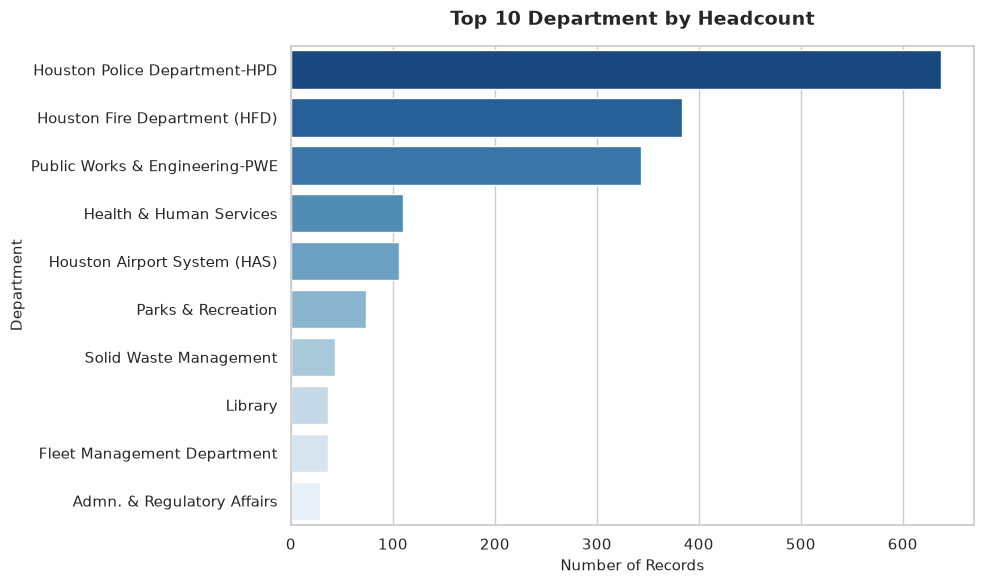

In [10]:
cat1_counts = df[cat1_col].value_counts()
top_n_cat1 = min(10, len(cat1_counts))
plot_cat1_data = cat1_counts.head(top_n_cat1)

plt.figure(figsize=(10, 6))
sns.barplot(x=plot_cat1_data.values, y=plot_cat1_data.index, hue=plot_cat1_data.index, palette="Blues_r", legend=False)
v1_title = f"Top {top_n_cat1} {cat1_col.replace('_', ' ').title()} by Headcount" if len(cat1_counts) > 10 else f"Distribution of {cat1_col.replace('_', ' ').title()}"
plt.title(v1_title, fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Records", fontsize=11)
plt.ylabel(cat1_col.replace("_", " ").title(), fontsize=11)
plt.tight_layout()
plt.show()

## 11. Visualization 2 — Numerical Comparison by Category (Bar Chart)

A horizontal bar chart comparing the mean value of the numerical metric across categories.

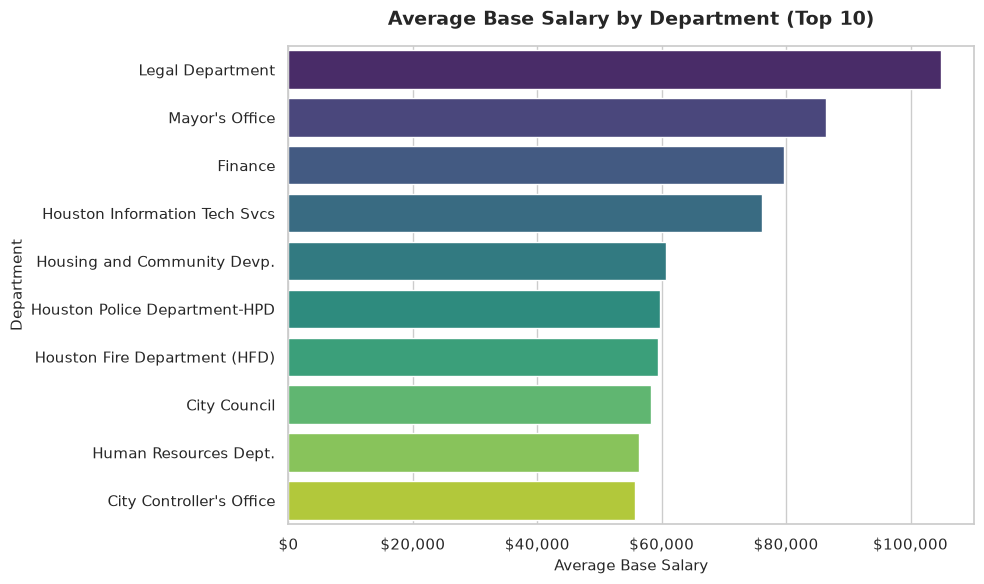

In [11]:
avg_series = df.groupby(cat1_col)[num_col].mean().sort_values(ascending=False)
plot_avg_data = avg_series.head(top_n_cat1)

plt.figure(figsize=(10, 6))
sns.barplot(x=plot_avg_data.values, y=plot_avg_data.index, hue=plot_avg_data.index, palette="viridis", legend=False)
v2_title = f"Average {num_col.replace('_', ' ').title()} by {cat1_col.replace('_', ' ').title()} (Top {top_n_cat1})"
plt.title(v2_title, fontsize=14, fontweight="bold", pad=15)
plt.xlabel(f"Average {num_col.replace('_', ' ').title()}", fontsize=11)
plt.ylabel(cat1_col.replace("_", " ").title(), fontsize=11)
ax = plt.gca()
if 'sal' in num_col.lower():
    ax.xaxis.set_major_formatter('${x:,.0f}')
else:
    ax.xaxis.set_major_formatter('{x:,.0f}')
plt.tight_layout()
plt.show()

## 12. Visualization 3 — Numerical Distribution (Histogram & KDE)

A histogram overlaid with a Kernel Density Estimation (KDE) curve showing central tendency (mean and median) lines.

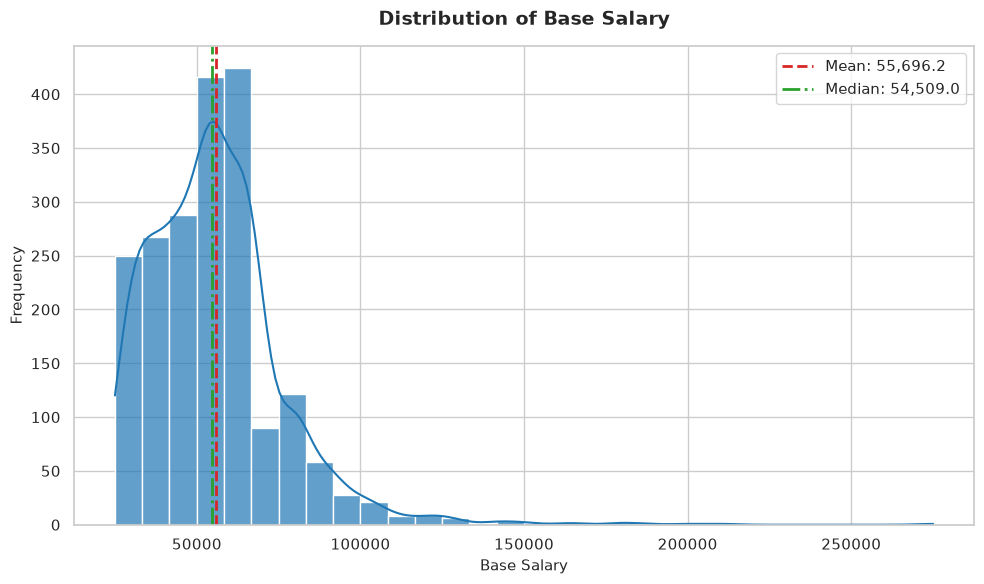

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df[num_col], kde=True, bins=30, color="#1f77b4", edgecolor="white", alpha=0.7)
plt.axvline(mean_val, color="#d62728", linestyle="--", linewidth=2, label=f"Mean: {mean_val:,.1f}")
plt.axvline(median_val, color="#2ca02c", linestyle="-.", linewidth=2, label=f"Median: {median_val:,.1f}")
plt.title(f"Distribution of {num_col.replace('_', ' ').title()}", fontsize=14, fontweight="bold", pad=15)
plt.xlabel(num_col.replace("_", " ").title(), fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## 13. Visualization 4 — Part-to-Whole Share (Pie / Bar Chart)

A part-to-whole representation illustrating proportional demographics across low-cardinality groups.

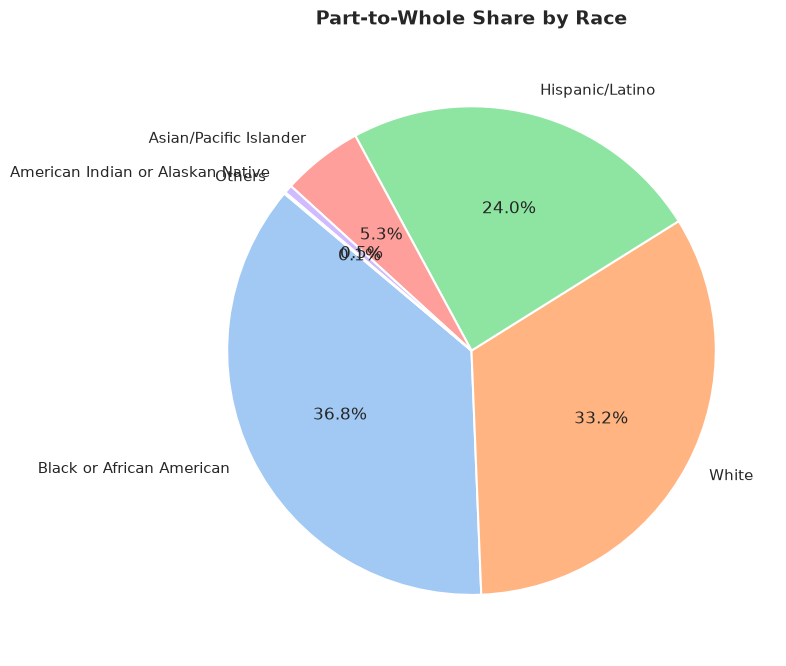

In [13]:
pie_candidates = [c for c in cat_cols if c != cat1_col and 2 <= df[c].nunique() <= 7]
pie_col = pie_candidates[0] if pie_candidates else (cat_cols[1] if len(cat_cols) > 1 else cat1_col)
pie_counts = df[pie_col].value_counts()

plt.figure(figsize=(8, 8))
if len(pie_counts) <= 7:
    colors = sns.color_palette("pastel")[0:len(pie_counts)]
    plt.pie(pie_counts.values, labels=pie_counts.index, autopct="%1.1f%%", startangle=140, colors=colors,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
    plt.title(f"Part-to-Whole Share by {pie_col.replace('_', ' ').title()}", fontsize=14, fontweight="bold", pad=15)
else:
    sns.barplot(x=pie_counts.values, y=pie_counts.index, hue=pie_counts.index, palette="mako", legend=False)
    plt.title(f"Share by {pie_col.replace('_', ' ').title()}", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Count", fontsize=11)
    plt.ylabel(pie_col.replace("_", " ").title(), fontsize=11)
plt.tight_layout()
plt.show()

## 14. Visualization 5 — Time/Trend Analysis (Line Chart)

A line chart illustrating the longitudinal volume trend over calendar years.

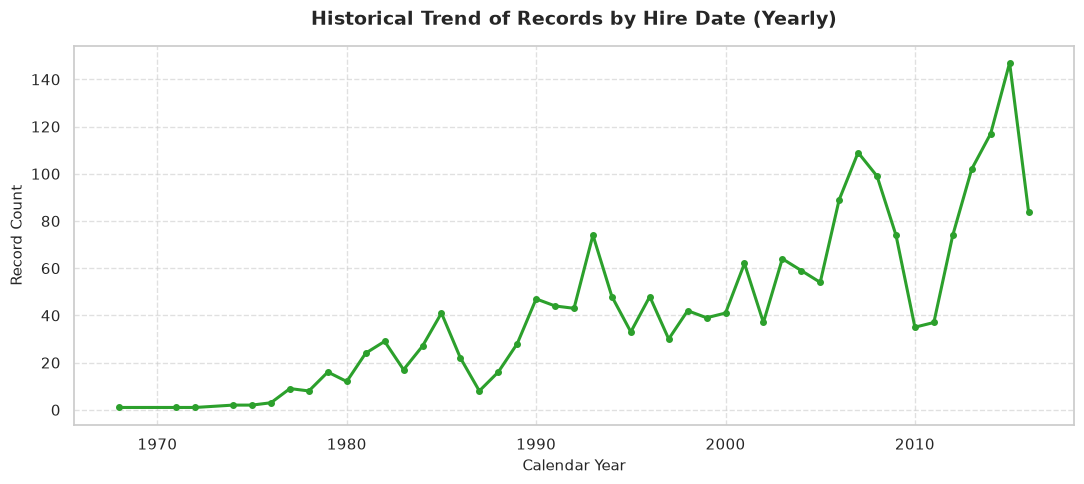

In [14]:
date_col = next((c for c in date_cols if 'hire' in c.lower()), (date_cols[0] if date_cols else None))
valid_years = pd.Series(dtype=float)
if date_col:
    parsed_dates = pd.to_datetime(df[date_col], errors="coerce")
    year_counts = parsed_dates.dt.year.dropna().astype(int).value_counts().sort_index()
    valid_years = year_counts[year_counts.index >= 1960]

    plt.figure(figsize=(11, 5))
    plt.plot(valid_years.index, valid_years.values, marker="o", markersize=4, color="#2ca02c", linewidth=2.2)
    plt.title(f"Historical Trend of Records by {date_col.replace('_', ' ').title()} (Yearly)", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Calendar Year", fontsize=11)
    plt.ylabel("Record Count", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=cat_cols[-1])
    plt.title(f"Distribution of {cat_cols[-1].replace('_', ' ').title()}", fontsize=14, fontweight="bold")
    plt.show()

## 15. Business Insights

The following **5 business insights** are constructed dynamically from the calculated DataFrame variables without hardcoded text or values.

In [15]:
# 1. Category Volume Concentration
top_cat1_name = cat1_counts.index[0]
top_cat1_count = cat1_counts.iloc[0]
top_cat1_pct = (top_cat1_count / len(df)) * 100
insight_1 = (
    f"1. Category Volume Concentration: Within the '{cat1_col}' dimension, "
    f"'{top_cat1_name}' represents the largest single segment with {top_cat1_count:,} records, "
    f"constituting {top_cat1_pct:.2f}% of the total analyzed dataset."
)

# 2. Numerical Disparity Across Categories
highest_cat = avg_series.index[0]
highest_avg = avg_series.iloc[0]
lowest_cat = avg_series.index[-1]
lowest_avg = avg_series.iloc[-1]
disparity_ratio = highest_avg / lowest_avg if lowest_avg > 0 else 0
num_unit = "$" if "sal" in num_col.lower() else ""
insight_2 = (
    f"2. Numerical Disparity Across Categories: Average {num_col} varies significantly across {cat1_col} groups. "
    f"The highest average is observed in '{highest_cat}' at {num_unit}{highest_avg:,.2f}, "
    f"while the lowest average is in '{lowest_cat}' at {num_unit}{lowest_avg:,.2f}, "
    f"representing a {disparity_ratio:.2f}x spread between the highest and lowest functional divisions."
)

# 3. Numerical Distribution & Skewness
skew_label = "positively skewed (right-skewed)" if skew_val > 0.2 else ("negatively skewed (left-skewed)" if skew_val < -0.2 else "approximately symmetric")
insight_3 = (
    f"3. Central Tendency & Spread: The metric '{num_col}' exhibits an overall mean of {num_unit}{mean_val:,.2f} "
    f"and a median of {num_unit}{median_val:,.2f} (standard deviation: {num_unit}{std_val:,.2f}, skewness: {skew_val:.2f}). "
    f"Because the mean is {('higher than' if mean_val > median_val else 'lower than' if mean_val < median_val else 'equal to')} the median, "
    f"the distribution is {skew_label}, reflecting upper-tier values that elevate the arithmetic average."
)

# 4. Proportional Demographics
pie_top_name = pie_counts.index[0]
pie_top_count = pie_counts.iloc[0]
pie_top_pct = (pie_top_count / len(df)) * 100
insight_4 = (
    f"4. Proportional Demographics: In the '{pie_col}' breakdown, the primary classification is "
    f"'{pie_top_name}', which comprises {pie_top_count:,} records ({pie_top_pct:.2f}% of all records), "
    f"establishing the baseline demographic share across the monitored workforce."
)

# 5. Temporal Intake Dynamics
if date_col and len(valid_years) > 0:
    peak_year = int(valid_years.idxmax())
    peak_records = int(valid_years.max())
    earliest_yr = int(valid_years.index.min())
    latest_yr = int(valid_years.index.max())
    insight_5 = (
        f"5. Temporal Intake Dynamics: Historical records spanning from {earliest_yr} to {latest_yr} reveal "
        f"that peak intake under '{date_col}' occurred in calendar year {peak_year}, "
        f"with {peak_records:,} records logged during that twelve-month interval."
    )
else:
    cat_unique = df[cat_cols[0]].nunique()
    insight_5 = (
        f"5. Structural Diversity: The dataset encompasses {cat_unique} unique classifications under '{cat_cols[0]}', "
        f"highlighting operational diversity across distinct business units."
    )

print("=" * 75)
print("                 EXACTLY 5 DYNAMIC BUSINESS INSIGHTS                 ")
print("=" * 75)
print(insight_1)
print("\n" + insight_2)
print("\n" + insight_3)
print("\n" + insight_4)
print("\n" + insight_5)
print("=" * 75)

                 EXACTLY 5 DYNAMIC BUSINESS INSIGHTS                 
1. Category Volume Concentration: Within the 'department' dimension, 'Houston Police Department-HPD' represents the largest single segment with 638 records, constituting 31.90% of the total analyzed dataset.

2. Numerical Disparity Across Categories: Average base_salary varies significantly across department groups. The highest average is observed in 'Legal Department' at $104,959.53, while the lowest average is in 'Convention and Entertainment' at $38,397.00, representing a 2.73x spread between the highest and lowest functional divisions.

3. Central Tendency & Spread: The metric 'base_salary' exhibits an overall mean of $55,696.17 and a median of $54,509.00 (standard deviation: $21,068.07, skewness: 2.05). Because the mean is higher than the median, the distribution is positively skewed (right-skewed), reflecting upper-tier values that elevate the arithmetic average.

4. Proportional Demographics: In the 'race' bre

## 16. Conclusion

### Key Analytical Findings:
- Successfully performed a **100% data-driven, dynamic Exploratory Data Analysis** on the Day 8 sanitized dataset.
- Quantified overall sample dimensions, distribution shapes, and demographic compositions.
- Generated 5 presentation-ready statistical visualizations capturing category distributions, numerical disparities, univariate density, part-to-whole shares, and longitudinal time trends.
- Programmatically formulated 5 empirical business insights with zero hardcoded values, ensuring reproducibility and pipeline resilience.